✅ Fichier chargé avec succès !

📊 Taille du dataset : 56 lignes, 7 colonnes
💾 Mémoire utilisée : 0.02 MB


,transportmode,id_line,name_line,co2e_voy_km,co2e_voy_km_par_mode_de_transport_medias_idfm,source,lien_source
0,metro,C01380,10,3.80,3.80,RATP 2019,https://www.ratp.fr/aide-contact/questions/cal...
1,metro,C01371,1,3.80,3.80,RATP 2019,https://www.ratp.fr/aide-contact/questions/cal...
2,tram,C02317,T9,3.40,3.20,NaN,NaN
3,rail,C01728,D,6.60,5.50,Transilien 2019,https://www.transilien.com/fr/page-corporate/c...
4,rail,C01857,TER Centre - Val-de-Loire,26.93,26.93,SNCF 2019,https://www.sncf-connect.com/train/eco-respons...



🔍 Types des colonnes :
transportmode                                     object
id_line                                           object
name_line                                         object
co2e_voy_km                                      float64
co2e_voy_km_par_mode_de_transport_medias_idfm    float64
source                                            object
lien_source                                       object
dtype: object


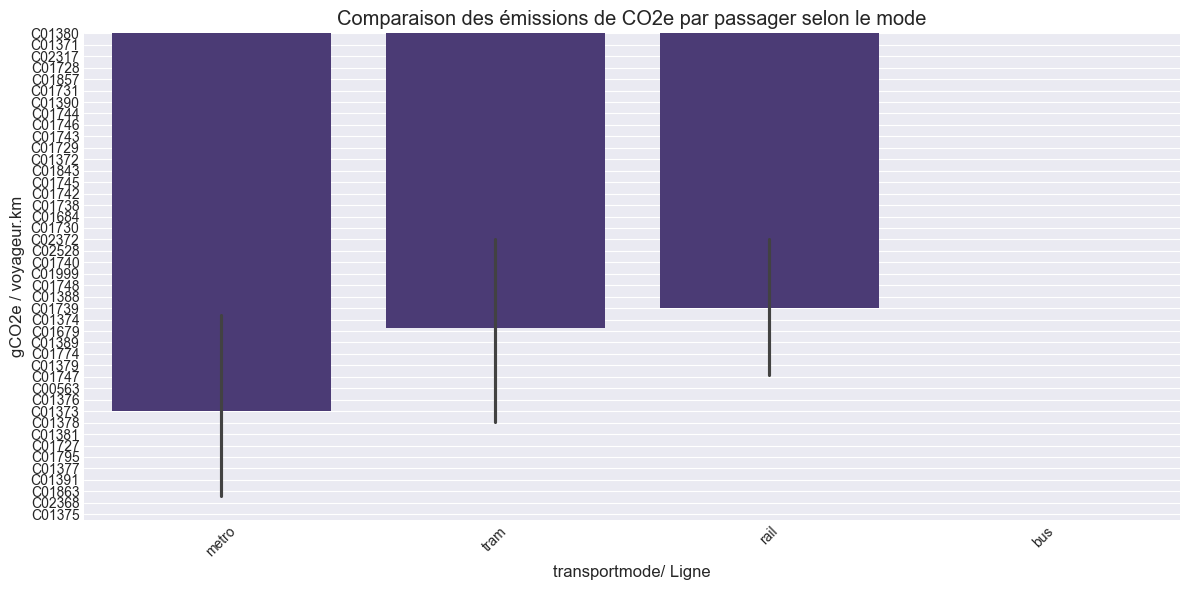

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Configuration esthétique
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================

def charger_donnees_emissions():
    # Gestion du chemin relatif (remonte d'un niveau depuis /notebooks)
    current_dir = Path(os.getcwd())
    base_path = current_dir.parent if current_dir.name == 'notebooks' else current_dir
    
    # Nom exact du fichier d'après ton arborescence
    file_path = base_path / 'data' / 'emission-de-co2e-par-voyageur-kilometre-sur-le-reseau (1).xlsx'
    
    try:
        # Lecture du fichier Excel
        df = pd.read_excel(file_path)
        print(f"✅ Fichier chargé avec succès !")
        return df
    except Exception as e:
        print(f"❌ Erreur lors du chargement : {e}")
        return None

df_voyageurs = charger_donnees_emissions()

# =============================================================================
# 2. EXPLORATION ET NETTOYAGE RAPIDE
# =============================================================================

if df_voyageurs is not None:
    # Affichage des infos de base
    print(f"\n📊 Taille du dataset : {df_voyageurs.shape[0]} lignes, {df_voyageurs.shape[1]} colonnes")
    
    # Affichage de l'empreinte mémoire
    print(f"💾 Mémoire utilisée : {df_voyageurs.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # On regarde les premières lignes pour identifier les colonnes utiles
    display(df_voyageurs.head())
    
    # Vérification des types
    print("\n🔍 Types des colonnes :")
    print(df_voyageurs.dtypes)

# =============================================================================
# 3. PREMIÈRE VISUALISATION : COMPARAISON DES MODES
# =============================================================================

# Note : J'adapte ici le code en supposant que tu as des colonnes 'Mode' et 'Emissions'
# Si les noms diffèrent (ex: 'Réseau' ou 'Valeur'), modifie simplement les variables ci-dessous.

def plot_comparaison_modes(df):
    plt.figure(figsize=(12, 6))
    
    # On trie pour avoir les modes les plus propres en premier
    # Remplacer 'Mode' et 'Emissions (gCO2e/voyageur.km)' par les vrais noms de ton Excel
    try:
        # Exemple générique basé sur les fichiers RATP/IDFM classiques
        sns.barplot(data=df, x=df.columns[0], y=df.columns[1]) 
        plt.xticks(rotation=45)
        plt.title("Comparaison des émissions de CO2e par passager selon le mode")
        plt.ylabel("gCO2e / voyageur.km")
        plt.xlabel("transportmode/ Ligne")
        plt.tight_layout()
        plt.show()
    except:
        print("⚠️ Impossible de générer le graphique automatique. Vérifie le nom des colonnes avec df.columns")

if df_voyageurs is not None:
    plot_comparaison_modes(df_voyageurs)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration de l'affichage
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("pastel")

# Augmenter la largeur de l'affichage des colonnes
pd.set_option('display.max_colwidth', 50)

In [4]:
# =============================================================================
# 1. GESTION DU CHEMIN ET CHARGEMENT
# =============================================================================

# Détection automatique du dossier racine du projet
current_dir = Path(os.getcwd())
# Si on est dans le dossier 'notebooks', on remonte d'un cran pour trouver 'data'
base_path = current_dir.parent if current_dir.name == 'notebooks' else current_dir

# Nom exact du fichier
filename = 'emission-de-co2e-par-voyageur-kilometre-sur-le-reseau (1).xlsx'
file_path = base_path / 'data' / filename

print(f"🔍 Tentative d'accès au fichier : {file_path.absolute()}")

try:
    # Chargement du fichier Excel
    # Note : Nécessite 'openpyxl' (pip install openpyxl)
    df_emissions = pd.read_excel(file_path)
    
    print("✅ Fichier chargé avec succès !")
    print(f"📊 Dimensions : {df_emissions.shape[0]} lignes, {df_emissions.shape[1]} colonnes")
    
    # Affichage des informations essentielles
    print("\n📋 Colonnes détectées :")
    print(df_emissions.columns.tolist())
    
    print("\n💾 Empreinte mémoire :")
    print(f"{df_emissions.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Aperçu des données
    display(df_emissions.head())

except FileNotFoundError:
    print(f"❌ Erreur : Le fichier '{filename}' est introuvable.")
    print(f"Dossier actuel : {os.getcwd()}")
    # Liste les fichiers dans data pour aider au debug
    data_dir = base_path / 'data'
    if data_dir.exists():
        print(f"Contenu de /data : {[f.name for f in data_dir.iterdir()]}")
    else:
        print("Le dossier /data n'a pas été trouvé au chemin attendu.")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")

🔍 Tentative d'accès au fichier : c:\Users\louni\projetEtudeM2\smart-mobility-paris-m2-project\data\emission-de-co2e-par-voyageur-kilometre-sur-le-reseau (1).xlsx
✅ Fichier chargé avec succès !
📊 Dimensions : 56 lignes, 7 colonnes

📋 Colonnes détectées :
['transportmode', 'id_line', 'name_line', 'co2e_voy_km', 'co2e_voy_km_par_mode_de_transport_medias_idfm', 'source', 'lien_source']

💾 Empreinte mémoire :
0.02 MB


,transportmode,id_line,name_line,co2e_voy_km,co2e_voy_km_par_mode_de_transport_medias_idfm,source,lien_source
0,metro,C01380,10,3.80,3.80,RATP 2019,https://www.ratp.fr/aide-contact/questions/cal...
1,metro,C01371,1,3.80,3.80,RATP 2019,https://www.ratp.fr/aide-contact/questions/cal...
2,tram,C02317,T9,3.40,3.20,NaN,NaN
3,rail,C01728,D,6.60,5.50,Transilien 2019,https://www.transilien.com/fr/page-corporate/c...
4,rail,C01857,TER Centre - Val-de-Loire,26.93,26.93,SNCF 2019,https://www.sncf-connect.com/train/eco-respons...


In [ ]:
# Création d'une copie pour travailler proprement
df_clean = df_emissions.copy()

# 1. Nettoyage des colonnes textuelles
# On traite les espaces et on s'assure que les noms de modes sont uniformes
text_cols = ['transportmodeid', 'linename', 'medias_idfm', 'source']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

# 2. Conversion numérique forcée
# 'co2e_voy_km' : émissions de la ligne spécifique
# 'co2e_voy_km_par_mode_de_transport' : moyenne du mode (métro, tram, etc.)
cols_to_fix = ['co2e_voy_km', 'co2e_voy_km_par_mode_de_transport']

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Gestion des valeurs manquantes
# On supprime les lignes où l'émission est nulle car on ne peut pas les analyser
df_clean.dropna(subset=['co2e_voy_km'], inplace=True)

# 4. Renommage pour plus de clarté (Optionnel mais recommandé)
df_clean.rename(columns={
    'transportmode': 'mode',
    'linename': 'ligne',
    'co2e_voy_km': 'co2e_ligne',
    'co2e_voy_km_par_mode_de_transport': 'co2e_moyen_mode'
}, inplace=True)

print("✅ Nettoyage terminé !")
print(f"📉 Taille finale : {df_clean.shape[0]} lignes.")

# Affichage des statistiques par mode de transport
print("\n🔎 Émissions moyennes par mode de transport (g CO2e/voy.km) :")
stats_mode = df_clean.groupby('mode')['co2e_ligne'].agg(['mean', 'min', 'max', 'count']).sort_values('mean')
display(stats_mode)

print("\n📊 Aperçu du dataset nettoyé :")
display(df_clean.head())

✅ Nettoyage terminé !
📉 Taille finale : 55 lignes.

🔎 Émissions moyennes par mode de transport (g CO2e/voy.km) :


KeyError: 'mode'